# Introduction
This project investigates the performance of Airbnb listings across three major U.S. cities with strong and diverse market characteristics: Chicago, Boston, and Seattle. The primary objective is to analyze the factors that influence listing price and demand, and to determine whether these factors vary across different urban markets. This topic is particularly relevant as Airbnb operates as a digital marketplace where pricing strategies, consumer preferences, and listing characteristics interact dynamically, creating significant variation in performance across listings. THIS NOTEBOOK TAKES AROUND 25 MINTES TO RUN.

In [25]:
# AIRBNB Final Project
# IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

# Data Loading
The dataset for this analysis is sourced from Inside Airbnb, a publicly available dataset containing detailed information on Airbnb listings across multiple cities. The data includes structured variables such as price, room type, neighborhood, availability, review metrics, and host characteristics, as well as unstructured guest review text. The three selected cities, Chicago, Boston, and Seattle, provide sufficient scale and diversity to enable meaningful statistical analysis and cross-city comparisons.

In [26]:
# LOAD DATA
DATA_DIR = "data"

chicago = pd.read_csv(f"{DATA_DIR}/listings_chicago.csv")
boston = pd.read_csv(f"{DATA_DIR}/listings_boston.csv")
seattle = pd.read_csv(f"{DATA_DIR}/listings_seattle.csv")

chicago["city"] = "Chicago"
boston["city"] = "Boston"
seattle["city"] = "Seattle"

# Data Cleaning
This section focuses on transforming raw Airbnb data into a consistent and usable format. Key preprocessing steps include cleaning and converting price variables, standardizing data types, and addressing missing or invalid entries. These transformations are critical to ensuring data quality and reliability, particularly given the presence of inconsistent formatting and incomplete fields in the original datasets.

In [27]:
# CLEANING FUNCTION
def clean_airbnb(df):
    df = df.copy()

    df["price_raw"] = df["price"].astype(str)

    df["price"] = (
        df["price"]
        .astype(str)
        .str.replace("$", "", regex=False)
        .str.replace(",", "", regex=False)
        .str.strip()
    )
    df["price"] = pd.to_numeric(df["price"], errors="coerce")

    df["host_response_rate"] = (
        df["host_response_rate"]
        .astype(str)
        .str.replace("%", "", regex=False)
        .str.strip()
        .replace("nan", np.nan)
        .replace("", np.nan)
    )
    df["host_response_rate"] = pd.to_numeric(df["host_response_rate"], errors="coerce")

    df["host_acceptance_rate"] = (
        df["host_acceptance_rate"]
        .astype(str)
        .str.replace("%", "", regex=False)
        .str.strip()
        .replace("nan", np.nan)
        .replace("", np.nan)
    )
    df["host_acceptance_rate"] = pd.to_numeric(df["host_acceptance_rate"], errors="coerce")

    binary_cols = ["host_is_superhost", "host_identity_verified", "instant_bookable"]
    for col in binary_cols:
        df[col] = df[col].astype(str).str.lower().replace("nan", np.nan)

    return df

chicago = clean_airbnb(chicago)
boston = clean_airbnb(boston)
seattle = clean_airbnb(seattle)

airbnb = pd.concat([chicago, boston, seattle], ignore_index=True)

In [28]:
# KEEP MAIN COLUMNS
eda_cols = [
    "city",
    "price",
    "price_raw",
    "room_type",
    "property_type",
    "accommodates",
    "bathrooms",
    "bedrooms",
    "beds",
    "minimum_nights",
    "maximum_nights",
    "availability_30",
    "availability_60",
    "availability_90",
    "availability_365",
    "number_of_reviews",
    "number_of_reviews_ltm",
    "number_of_reviews_l30d",
    "reviews_per_month",
    "review_scores_rating",
    "review_scores_cleanliness",
    "review_scores_checkin",
    "review_scores_communication",
    "review_scores_location",
    "review_scores_value",
    "estimated_occupancy_l365d",
    "estimated_revenue_l365d",
    "host_is_superhost",
    "host_response_rate",
    "host_acceptance_rate",
    "host_identity_verified",
    "instant_bookable",
    "neighbourhood_cleansed",
    "latitude",
    "longitude"
]

eda = airbnb[eda_cols].copy()
eda = eda.drop_duplicates().copy()

# Feature Engineering
In this section, new variables are constructed to enhance analytical depth and model performance. Price is log-transformed to mitigate extreme right-skew caused by high-value outliers, and binary indicators such as high-price and high-revenue categories are introduced to support classification modeling. Additional transformations, including encoding host and listing attributes, allow the dataset to better capture nonlinear relationships and complex interactions among features.

In [29]:
# BUILD ANALYSIS DATASETS
# Keep rows with usable price
eda_price = eda.dropna(subset=["price"]).copy()
eda_price = eda_price[eda_price["price"] > 0].copy()
eda_price["log_price"] = np.log1p(eda_price["price"])

# Remove hotel rooms for cleaner city comparisons
eda_main = eda_price[eda_price["room_type"] != "Hotel room"].copy()

# Light outlier trim using IQR
q1 = eda_main["price"].quantile(0.25)
q3 = eda_main["price"].quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr

eda_main_no_outliers = eda_main[eda_main["price"] <= upper_bound].copy()

# Exploratory Analysis
Exploratory analysis reveals substantial variation in Airbnb pricing and listing characteristics across the three cities. Price distributions are highly right-skewed, with Chicago exhibiting particularly extreme outliers that inflate the mean relative to the median. Correlation analysis indicates that variables such as accommodates, bathrooms, bedrooms, and beds are positively associated with price, while review volume and occupancy measures show weaker or slightly negative relationships. These findings highlight the importance of both structural property features and market dynamics, and they motivate the use of log-transformed price and robust modeling techniques. This section evaluates initial patterns in the data to test the proposed hypotheses and identify potential drivers of listing performance.



In [30]:
# OVERVIEW / DATA QUALITY
print("FULL DATASET SHAPE:", eda.shape)
print("PRICE-READY DATASET SHAPE:", eda_price.shape)
print("MAIN ANALYSIS DATASET SHAPE (NO HOTEL ROOMS):", eda_main.shape)
print("OUTLIER-TRIMMED MAIN DATASET SHAPE:", eda_main_no_outliers.shape)

print("\nLISTINGS BY CITY (ALL ROWS):")
print(eda["city"].value_counts())

print("\nLISTINGS BY CITY (PRICE READY):")
print(eda_price["city"].value_counts())

print("\nDUPLICATE ROWS REMOVED:")
print(airbnb.shape[0] - eda.shape[0])

print("\nMISSING VALUES:")
print(eda.isna().sum().sort_values(ascending=False))

missing_table = (
    eda.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .reset_index()
)
missing_table.columns = ["column", "missing_percent"]

print("\nMISSINGNESS TABLE:")
print(missing_table)

print("\nSAMPLE OF ROWS WITH MISSING PRICE:")
print(eda[eda["price"].isna()][["city", "price_raw", "room_type", "property_type"]].head(15))

FULL DATASET SHAPE: (20006, 35)
PRICE-READY DATASET SHAPE: (17515, 36)
MAIN ANALYSIS DATASET SHAPE (NO HOTEL ROOMS): (17361, 36)
OUTLIER-TRIMMED MAIN DATASET SHAPE: (16210, 36)

LISTINGS BY CITY (ALL ROWS):
city
Chicago    8614
Seattle    6983
Boston     4409
Name: count, dtype: int64

LISTINGS BY CITY (PRICE READY):
city
Chicago    7805
Seattle    6209
Boston     3501
Name: count, dtype: int64

DUPLICATE ROWS REMOVED:
69

MISSING VALUES:
review_scores_checkin          3475
review_scores_value            3475
review_scores_location         3475
review_scores_rating           3473
review_scores_communication    3473
review_scores_cleanliness      3473
reviews_per_month              3473
host_response_rate             2764
estimated_revenue_l365d        2491
price                          2491
host_acceptance_rate           2456
beds                           2333
bathrooms                      2328
host_identity_verified          969
host_is_superhost               851
bedrooms         

In [31]:
# DESCRIPTIVE TABLES
price_summary_city = (
    eda_main.groupby("city")["price"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .sort_values("median", ascending=False)
)

print("\nPRICE SUMMARY BY CITY (NO HOTEL ROOMS):")
print(price_summary_city)

review_summary_city = (
    eda_main.groupby("city")["review_scores_rating"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .sort_values("mean", ascending=False)
)

print("\nREVIEW SCORE SUMMARY BY CITY:")
print(review_summary_city)

room_dist = pd.crosstab(eda_main["city"], eda_main["room_type"], normalize="index") * 100
print("\nROOM TYPE DISTRIBUTION BY CITY (%):")
print(room_dist.round(2))

review_city_compare = eda_main.groupby("city").agg(
    avg_price=("price", "mean"),
    median_price=("price", "median"),
    avg_reviews=("number_of_reviews", "mean"),
    median_reviews=("number_of_reviews", "median"),
    avg_rating=("review_scores_rating", "mean"),
    avg_reviews_per_month=("reviews_per_month", "mean")
).round(2)

print("\nREVIEW-FOCUSED CITY COMPARISON:")
print(review_city_compare)

availability_summary = (
    eda_main.groupby("city")["availability_365"]
    .agg(["mean", "median", "std"])
    .round(2)
)
print("\nAVAILABILITY_365 SUMMARY BY CITY:")
print(availability_summary)

city_report_table = eda_main.groupby("city").agg(
    listings=("price", "count"),
    avg_price=("price", "mean"),
    median_price=("price", "median"),
    avg_rating=("review_scores_rating", "mean"),
    avg_reviews=("number_of_reviews", "mean"),
    avg_reviews_per_month=("reviews_per_month", "mean"),
    avg_availability_365=("availability_365", "mean"),
    avg_accommodates=("accommodates", "mean")
).round(2)

print("\nCITY REPORT TABLE:")
print(city_report_table)

city_roomtype_report_table = (
    eda_main.groupby(["city", "room_type"])
    .agg(
        listings=("price", "count"),
        avg_price=("price", "mean"),
        median_price=("price", "median"),
        avg_rating=("review_scores_rating", "mean"),
        avg_reviews=("number_of_reviews", "mean")
    )
    .round(2)
)

print("\nCITY x ROOM TYPE REPORT TABLE:")
print(city_roomtype_report_table)


PRICE SUMMARY BY CITY (NO HOTEL ROOMS):
         count   mean  median      std   min       max
city                                                  
Boston    3460 253.58  202.00   354.59 26.00 13,000.00
Chicago   7736 369.67  152.00 2,688.85 13.00 50,000.00
Seattle   6165 233.89  148.00 1,514.93 15.00 50,037.00

REVIEW SCORE SUMMARY BY CITY:
         count  mean  median  std  min  max
city                                       
Seattle   5442  4.81    4.90 0.33 1.00 5.00
Chicago   6298  4.77    4.87 0.41 1.00 5.00
Boston    2760  4.74    4.83 0.40 1.00 5.00

ROOM TYPE DISTRIBUTION BY CITY (%):
room_type  Entire home/apt  Private room  Shared room
city                                                 
Boston               71.88         28.03         0.09
Chicago              79.93         19.65         0.43
Seattle              83.52         16.09         0.39

REVIEW-FOCUSED CITY COMPARISON:
         avg_price  median_price  avg_reviews  median_reviews  avg_rating  \
city            

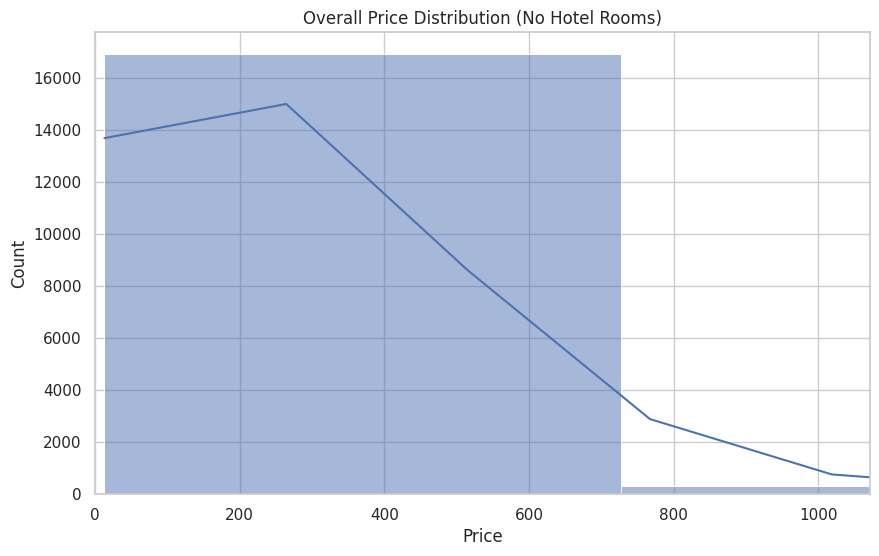

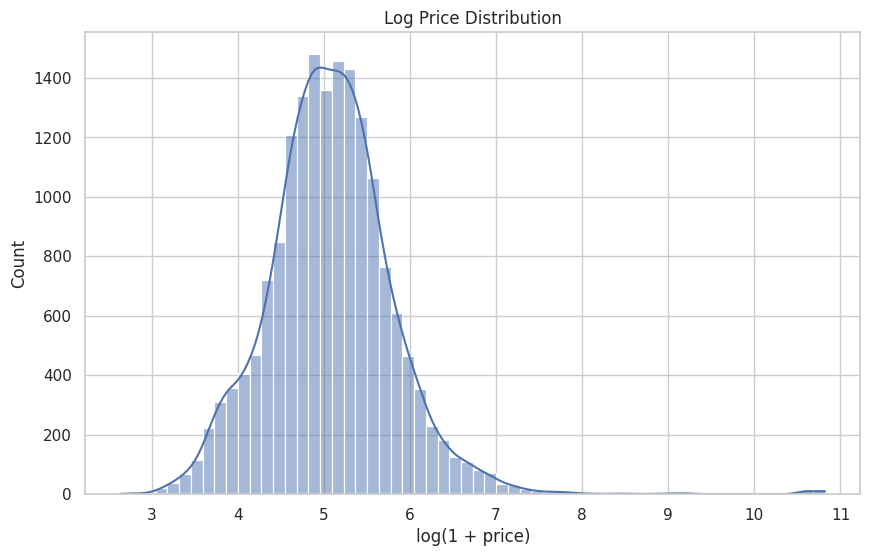

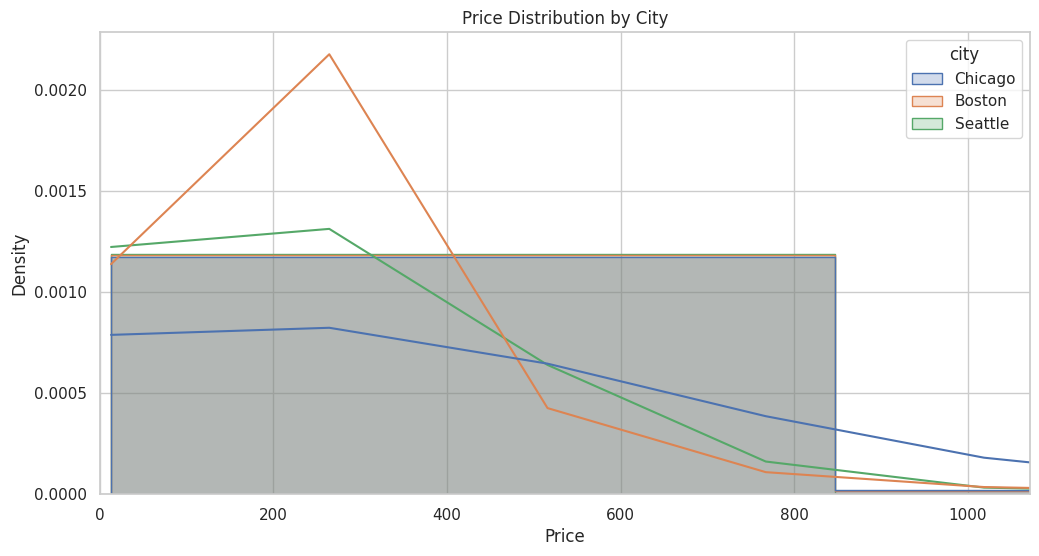

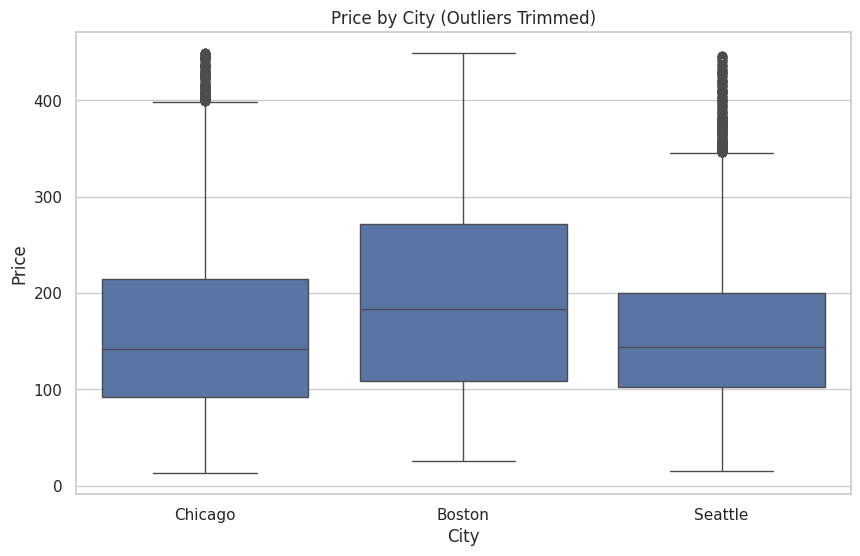

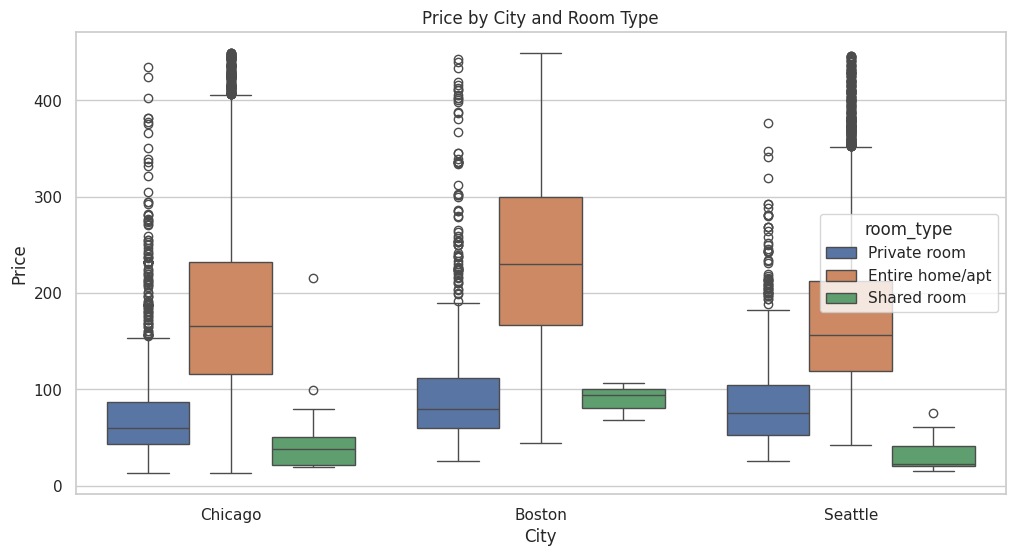

In [32]:
# PRICE VISUALS
plt.figure(figsize=(10, 6))
sns.histplot(data=eda_main, x="price", bins=70, kde=True)
plt.title("Overall Price Distribution (No Hotel Rooms)")
plt.xlabel("Price")
plt.ylabel("Count")
plt.xlim(0, eda_main["price"].quantile(0.99))
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(data=eda_main, x="log_price", bins=60, kde=True)
plt.title("Log Price Distribution")
plt.xlabel("log(1 + price)")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(12, 6))
sns.histplot(
    data=eda_main,
    x="price",
    hue="city",
    bins=60,
    stat="density",
    common_norm=False,
    element="step",
    kde=True
)
plt.title("Price Distribution by City")
plt.xlabel("Price")
plt.ylabel("Density")
plt.xlim(0, eda_main["price"].quantile(0.99))
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(data=eda_main_no_outliers, x="city", y="price")
plt.title("Price by City (Outliers Trimmed)")
plt.xlabel("City")
plt.ylabel("Price")
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(data=eda_main_no_outliers, x="city", y="price", hue="room_type")
plt.title("Price by City and Room Type")
plt.xlabel("City")
plt.ylabel("Price")
plt.show()


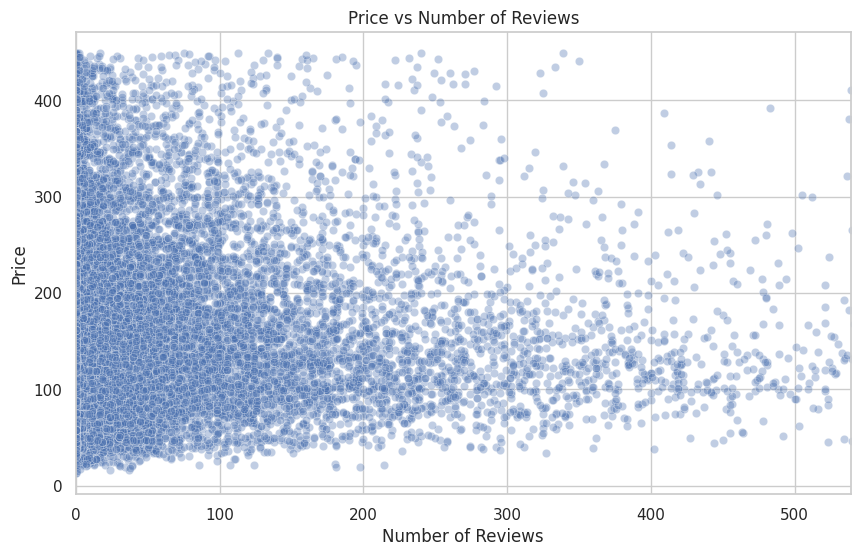

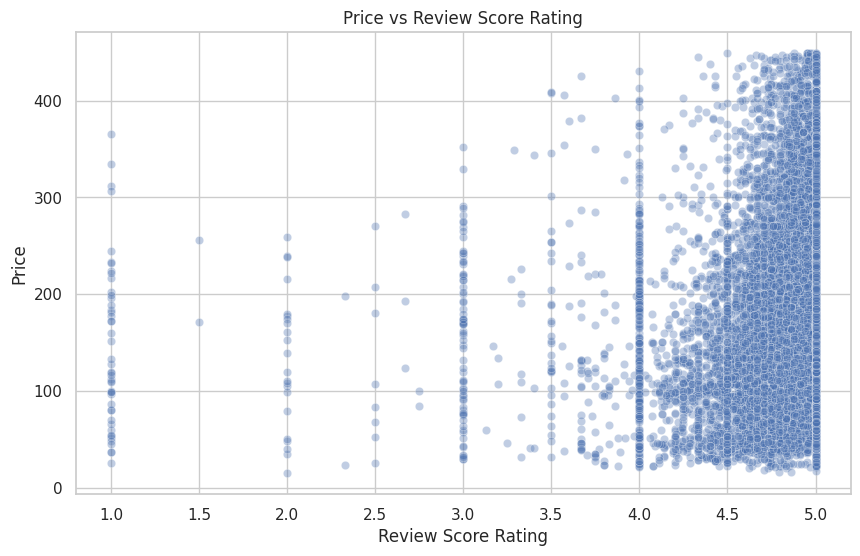

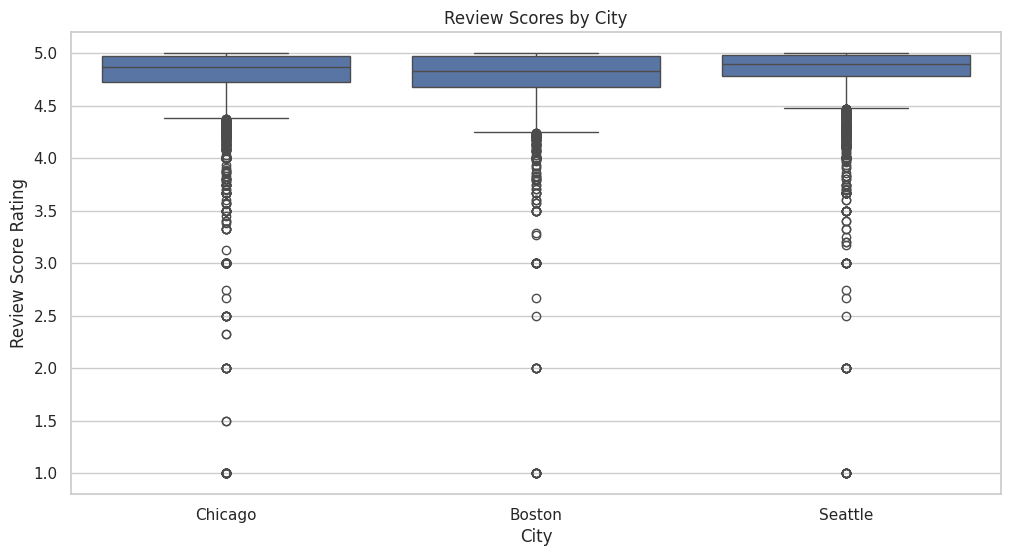

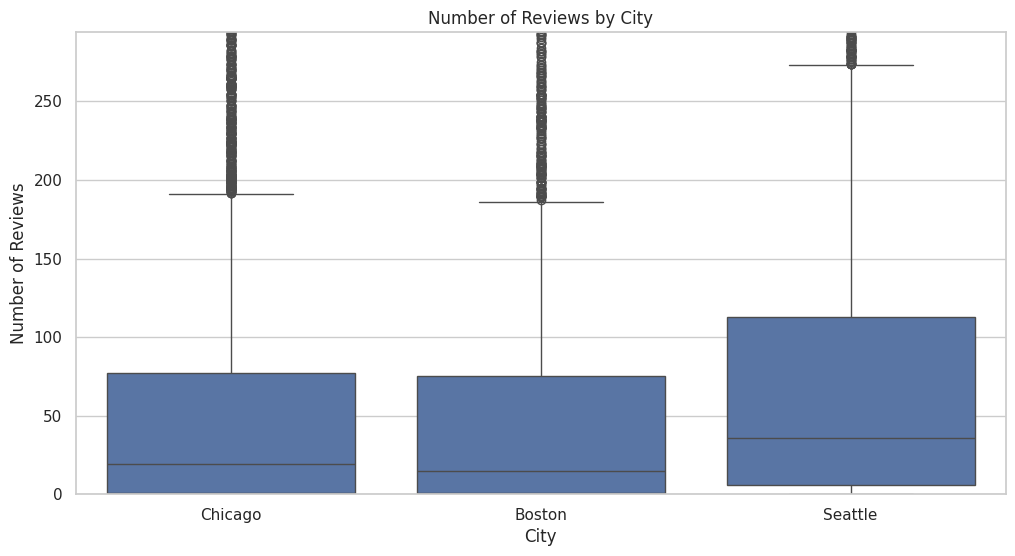

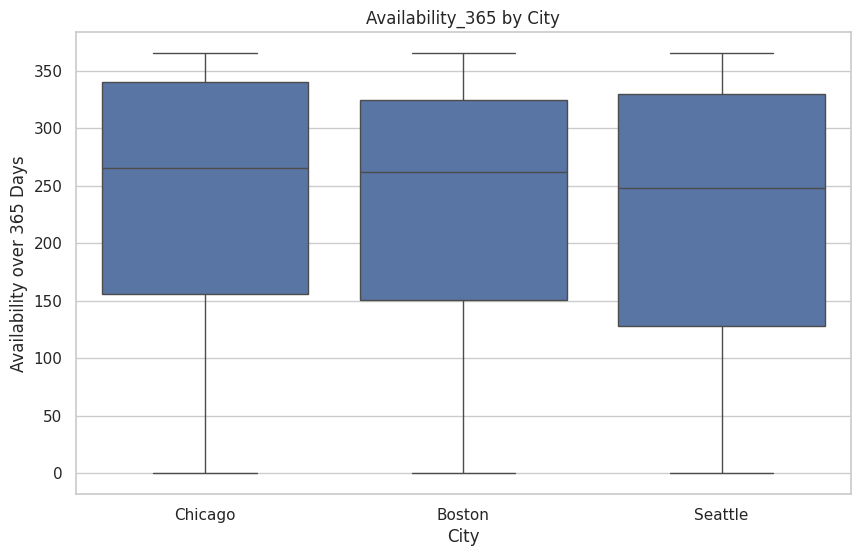

In [33]:
# REVIEWS / DEMAND VISUALS
plt.figure(figsize=(10, 6))
sns.scatterplot(data=eda_main_no_outliers, x="number_of_reviews", y="price", alpha=0.35)
plt.title("Price vs Number of Reviews")
plt.xlabel("Number of Reviews")
plt.ylabel("Price")
plt.xlim(0, eda_main_no_outliers["number_of_reviews"].quantile(0.99))
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=eda_main_no_outliers, x="review_scores_rating", y="price", alpha=0.35)
plt.title("Price vs Review Score Rating")
plt.xlabel("Review Score Rating")
plt.ylabel("Price")
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(data=eda_main, x="city", y="review_scores_rating")
plt.title("Review Scores by City")
plt.xlabel("City")
plt.ylabel("Review Score Rating")
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(data=eda_main, x="city", y="number_of_reviews")
plt.title("Number of Reviews by City")
plt.xlabel("City")
plt.ylabel("Number of Reviews")
plt.ylim(0, eda_main["number_of_reviews"].quantile(0.95))
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(data=eda_main, x="city", y="availability_365")
plt.title("Availability_365 by City")
plt.xlabel("City")
plt.ylabel("Availability over 365 Days")
plt.show()

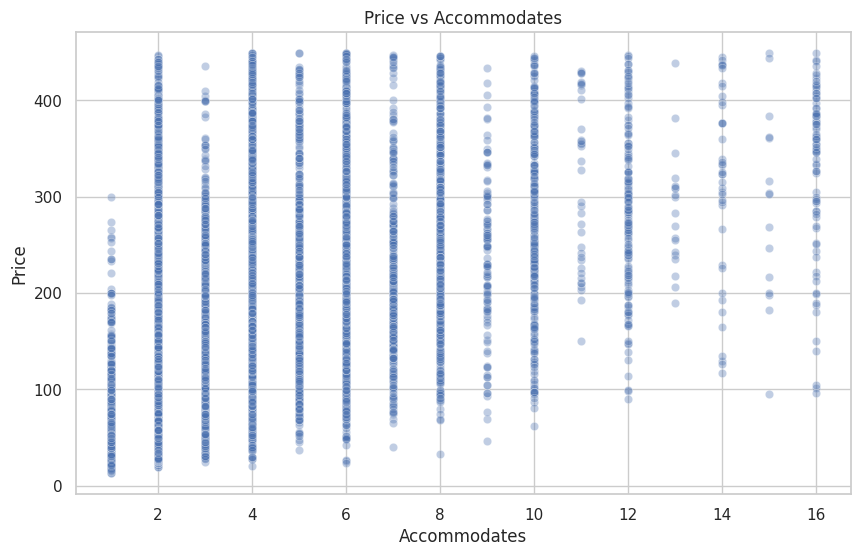

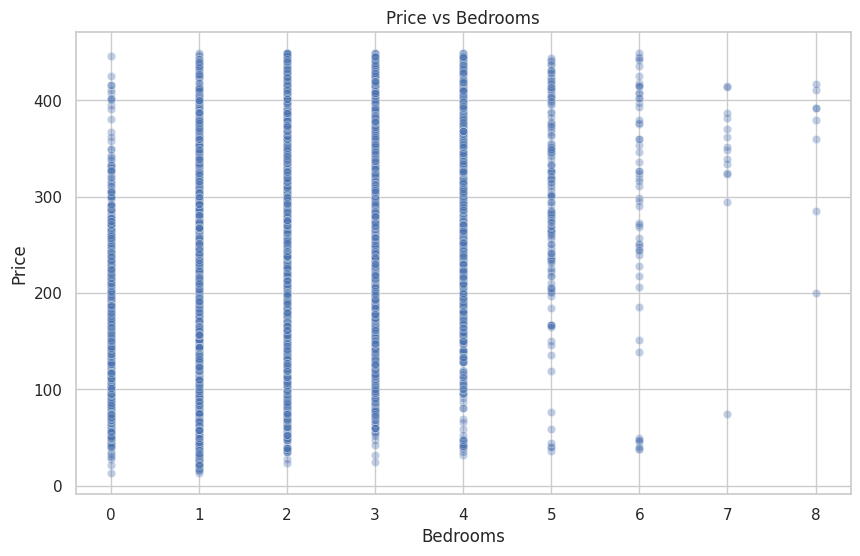

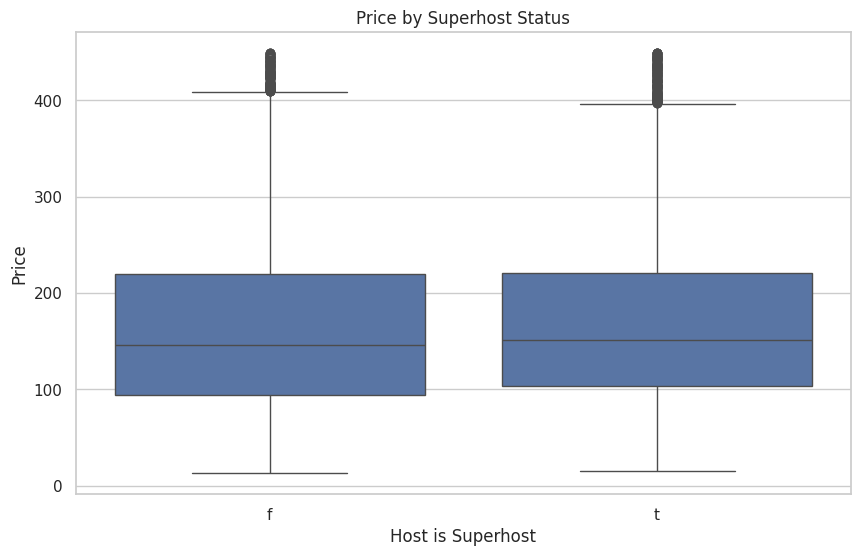

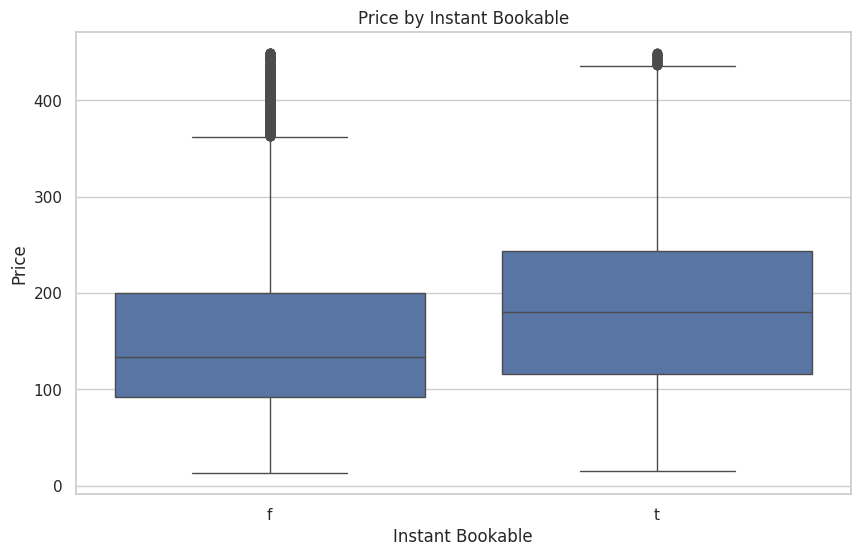


PRICE BY SUPERHOST STATUS:
                   count   mean  median
host_is_superhost                      
f                   8478 385.49  155.00
t                   8100 214.22  159.00

PRICE BY INSTANT BOOKABLE:
                  count   mean  median
instant_bookable                      
f                 11124 203.61  141.00
t                  6237 467.24  189.00


In [34]:
# SIZE / HOST FEATURES
plt.figure(figsize=(10, 6))
sns.scatterplot(data=eda_main_no_outliers, x="accommodates", y="price", alpha=0.35)
plt.title("Price vs Accommodates")
plt.xlabel("Accommodates")
plt.ylabel("Price")
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=eda_main_no_outliers, x="bedrooms", y="price", alpha=0.35)
plt.title("Price vs Bedrooms")
plt.xlabel("Bedrooms")
plt.ylabel("Price")
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(data=eda_main_no_outliers, x="host_is_superhost", y="price")
plt.title("Price by Superhost Status")
plt.xlabel("Host is Superhost")
plt.ylabel("Price")
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(data=eda_main_no_outliers, x="instant_bookable", y="price")
plt.title("Price by Instant Bookable")
plt.xlabel("Instant Bookable")
plt.ylabel("Price")
plt.show()

superhost_summary = eda_main.groupby("host_is_superhost")["price"].agg(["count", "mean", "median"]).round(2)
instant_book_summary = eda_main.groupby("instant_bookable")["price"].agg(["count", "mean", "median"]).round(2)

print("\nPRICE BY SUPERHOST STATUS:")
print(superhost_summary)

print("\nPRICE BY INSTANT BOOKABLE:")
print(instant_book_summary)

In [35]:
# NEIGHBORHOOD ANALYSIS
top_neighborhoods = (
    eda_main.groupby(["city", "neighbourhood_cleansed"])
    .size()
    .reset_index(name="listing_count")
    .sort_values(["city", "listing_count"], ascending=[True, False])
)

print("\nTOP 10 NEIGHBORHOODS BY LISTING COUNT IN EACH CITY:")
print(top_neighborhoods.groupby("city").head(10))

neigh_price = (
    eda_main.groupby(["city", "neighbourhood_cleansed"])
    .agg(
        avg_price=("price", "mean"),
        median_price=("price", "median"),
        listing_count=("price", "count")
    )
    .reset_index()
)

neigh_price_filtered = neigh_price[neigh_price["listing_count"] >= 10].copy()

print("\nTOP 10 MOST EXPENSIVE NEIGHBORHOODS IN EACH CITY (MIN 10 LISTINGS, SORTED BY MEDIAN PRICE):")
print(
    neigh_price_filtered
    .sort_values(["city", "median_price"], ascending=[True, False])
    .groupby("city")
    .head(10)
)


TOP 10 NEIGHBORHOODS BY LISTING COUNT IN EACH CITY:
        city neighbourhood_cleansed  listing_count
7     Boston             Dorchester            475
1     Boston               Back Bay            297
8     Boston               Downtown            278
19    Boston                Roxbury            256
4     Boston               Brighton            233
22    Boston              South End            209
3     Boston            Beacon Hill            197
10    Boston                 Fenway            197
12    Boston          Jamaica Plain            180
9     Boston            East Boston            166
72   Chicago        Near North Side            883
99   Chicago              West Town            691
74   Chicago         Near West Side            558
62   Chicago              Lake View            518
66   Chicago                   Loop            479
65   Chicago           Logan Square            426
63   Chicago           Lincoln Park            269
73   Chicago        Near Sout

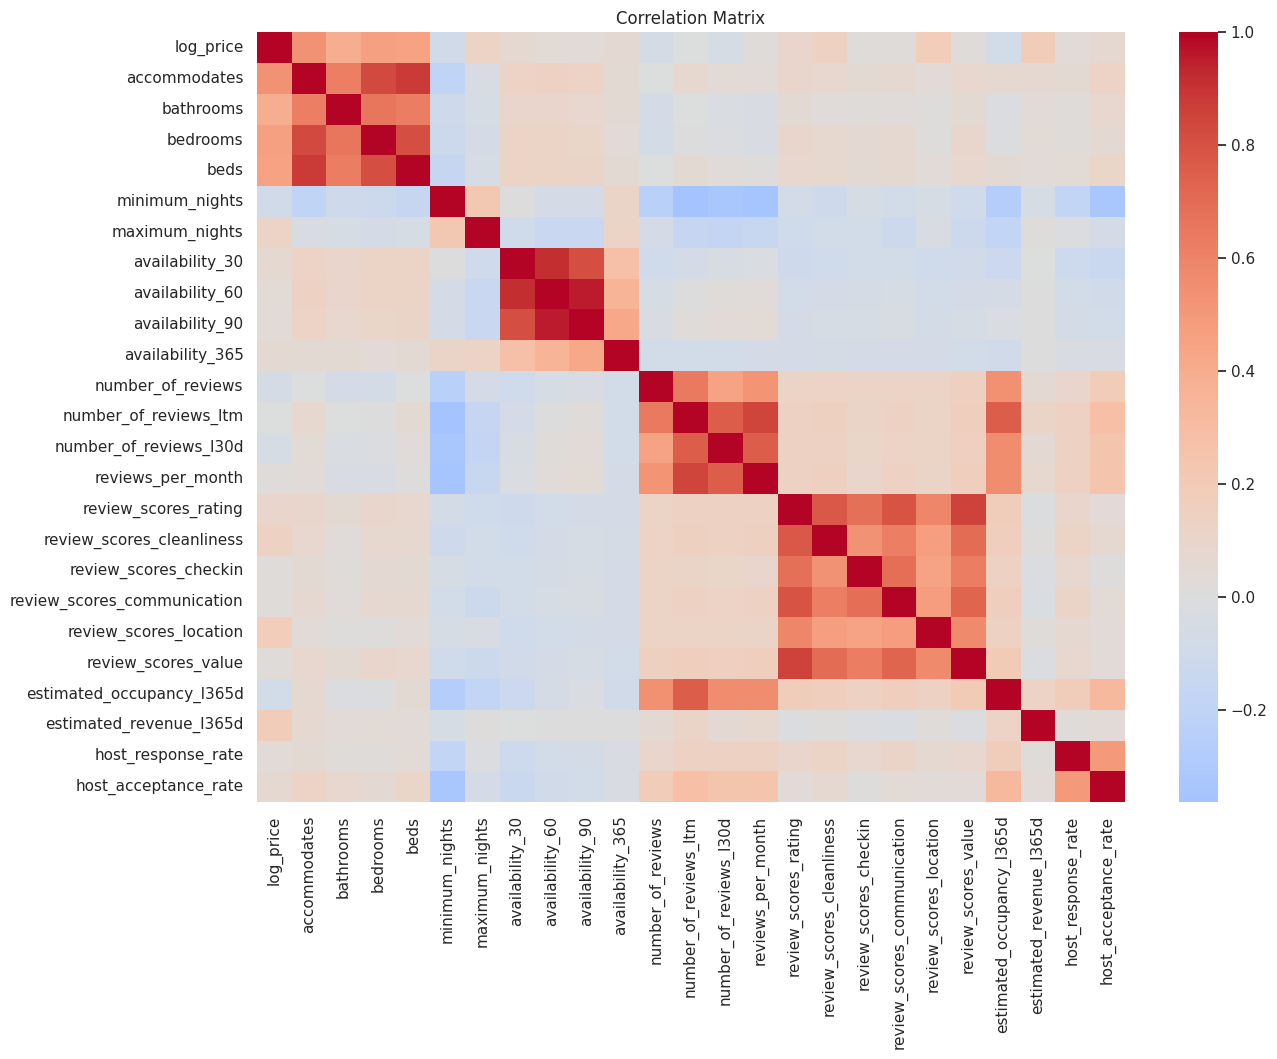


CORRELATIONS WITH LOG_PRICE:
log_price                      1.00
accommodates                   0.54
bedrooms                       0.46
beds                           0.46
bathrooms                      0.39
estimated_revenue_l365d        0.20
review_scores_location         0.18
review_scores_cleanliness      0.15
maximum_nights                 0.12
review_scores_rating           0.10
availability_30                0.07
host_acceptance_rate           0.06
availability_365               0.06
availability_60                0.05
host_response_rate             0.04
availability_90                0.03
review_scores_value            0.02
reviews_per_month              0.02
review_scores_communication    0.02
review_scores_checkin          0.02
number_of_reviews_ltm         -0.01
number_of_reviews_l30d        -0.04
number_of_reviews             -0.06
estimated_occupancy_l365d     -0.09
minimum_nights                -0.09
Name: log_price, dtype: float64


In [36]:
# CORRELATIONS
corr_cols = [
    "log_price",
    "accommodates",
    "bathrooms",
    "bedrooms",
    "beds",
    "minimum_nights",
    "maximum_nights",
    "availability_30",
    "availability_60",
    "availability_90",
    "availability_365",
    "number_of_reviews",
    "number_of_reviews_ltm",
    "number_of_reviews_l30d",
    "reviews_per_month",
    "review_scores_rating",
    "review_scores_cleanliness",
    "review_scores_checkin",
    "review_scores_communication",
    "review_scores_location",
    "review_scores_value",
    "estimated_occupancy_l365d",
    "estimated_revenue_l365d",
    "host_response_rate",
    "host_acceptance_rate"
]

corr_matrix = eda_main[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

print("\nCORRELATIONS WITH LOG_PRICE:")
print(corr_matrix["log_price"].sort_values(ascending=False))

In [37]:
# OUTLIER CHECKS
print("\nTOP 15 HIGHEST PRICED LISTINGS:")
print(
    eda_price[
        [
            "city",
            "price",
            "room_type",
            "property_type",
            "accommodates",
            "bedrooms",
            "review_scores_rating",
            "neighbourhood_cleansed"
        ]
    ]
    .sort_values("price", ascending=False)
    .head(15)
)

print("\nPRICE PERCENTILES:")
print(eda_price["price"].quantile([0.50, 0.75, 0.90, 0.95, 0.99]))


TOP 15 HIGHEST PRICED LISTINGS:
          city     price        room_type              property_type  \
18047  Seattle 50,039.00       Hotel room     Room in boutique hotel   
18045  Seattle 50,039.00       Hotel room     Room in boutique hotel   
18052  Seattle 50,037.00  Entire home/apt  Entire serviced apartment   
18053  Seattle 50,037.00  Entire home/apt  Entire serviced apartment   
18054  Seattle 50,037.00  Entire home/apt  Entire serviced apartment   
4800   Chicago 50,032.00       Hotel room              Room in hotel   
5529   Chicago 50,000.00     Private room              Room in hotel   
5448   Chicago 50,000.00     Private room              Room in hotel   
5450   Chicago 50,000.00     Private room              Room in hotel   
5449   Chicago 50,000.00     Private room              Room in hotel   
12904   Boston 50,000.00       Hotel room              Room in hotel   
12906   Boston 50,000.00       Hotel room              Room in hotel   
12905   Boston 50,000.00       

In [38]:
# BUILD FINAL MODELING DATASET
final_df = eda_main.copy()

# Binary columns
binary_map = {
    "t": 1, "f": 0,
    "True": 1, "False": 0,
    True: 1, False: 0
}

binary_cols = [
    "host_is_superhost",
    "host_has_profile_pic",
    "host_identity_verified",
    "instant_bookable"
]

for col in binary_cols:
    if col in final_df.columns:
        final_df[col] = final_df[col].map(binary_map)

# Amenity count
if "amenities" in final_df.columns:
    final_df["amenity_count"] = final_df["amenities"].fillna("").apply(
        lambda x: 0 if x == "" else len([a for a in str(x).strip("{}").split(",") if a.strip() != ""])
    )

# Host tenure
if "host_since" in final_df.columns:
    final_df["host_since"] = pd.to_datetime(final_df["host_since"], errors="coerce")
    ref_date = pd.to_datetime(final_df["host_since"].max())
    final_df["host_tenure_days"] = (ref_date - final_df["host_since"]).dt.days

# Review history
for c in ["first_review", "last_review"]:
    if c in final_df.columns:
        final_df[c] = pd.to_datetime(final_df[c], errors="coerce")

if "first_review" in final_df.columns and "last_review" in final_df.columns:
    final_df["review_history_days"] = (final_df["last_review"] - final_df["first_review"]).dt.days

# Log transforms
final_df["log_price"] = np.log1p(final_df["price"])

if "number_of_reviews" in final_df.columns:
    final_df["log_number_of_reviews"] = np.log1p(final_df["number_of_reviews"])

if "estimated_revenue_l365d" in final_df.columns:
    final_df["log_estimated_revenue_l365d"] = np.log1p(final_df["estimated_revenue_l365d"])

# Classification targets
final_df["high_price"] = (final_df["price"] >= final_df["price"].median()).astype(int)

if "estimated_revenue_l365d" in final_df.columns:
    final_df["high_revenue"] = (
        final_df["estimated_revenue_l365d"] >= final_df["estimated_revenue_l365d"].median()
    ).astype(int)

if "reviews_per_month" in final_df.columns:
    final_df["high_demand"] = (
        final_df["reviews_per_month"] >= final_df["reviews_per_month"].median()
    ).astype(int)

print("Final dataset shape:", final_df.shape)
final_df.head()

Final dataset shape: (17361, 41)


,city,price,price_raw,room_type,property_type,accommodates,bathrooms,bedrooms,beds,minimum_nights,maximum_nights,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,reviews_per_month,review_scores_rating,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,estimated_occupancy_l365d,estimated_revenue_l365d,host_is_superhost,host_response_rate,host_acceptance_rate,host_identity_verified,instant_bookable,neighbourhood_cleansed,latitude,longitude,log_price,log_number_of_reviews,log_estimated_revenue_l365d,high_price,high_revenue,high_demand
0,Chicago,119.00,$119.00,Private room,Private room in condo,1,1.00,1.00,1.00,3,90,13,43,73,348,257,10,0,1.97,4.99,4.99,4.99,4.98,4.95,4.93,60,"7,140.00",0.00,100.00,81.00,1.00,0,Hyde Park,41.79,-87.59,4.79,5.55,8.87,0,0,1
1,Chicago,89.00,$89.00,Entire home/apt,Entire rental unit,2,1.00,1.00,1.00,2,60,6,23,39,302,595,47,3,3.01,4.73,4.58,4.91,4.88,4.90,4.77,255,"22,695.00",1.00,100.00,100.00,1.00,0,West Town,41.90,-87.68,4.50,6.39,10.03,0,1,1
2,Chicago,203.00,$203.00,Entire home/apt,Entire rental unit,4,1.00,2.00,2.00,4,120,2,26,50,325,129,24,2,0.93,4.74,4.82,4.84,4.88,4.98,4.73,192,"38,976.00",1.00,95.00,89.00,1.00,1,Lincoln Park,41.91,-87.64,5.32,4.87,10.57,1,1,0
3,Chicago,339.00,$339.00,Private room,Room in boutique hotel,3,1.00,1.00,1.00,2,10,12,37,67,156,19,3,1,0.15,4.95,5.00,5.00,5.00,5.00,4.68,18,"6,102.00",0.00,100.00,57.00,0.00,0,Lincoln Park,41.92,-87.65,5.83,3.00,8.72,1,0,0
4,Chicago,258.00,$258.00,Entire home/apt,Entire loft,6,2.00,3.00,3.00,2,10,14,44,74,74,265,37,2,1.47,4.83,4.77,4.94,4.88,4.93,4.73,222,"57,276.00",1.00,100.00,85.00,1.00,0,Logan Square,41.92,-87.68,5.56,5.58,10.96,1,1,0


In [39]:
# FILTER SPARSE NEIGHBORHOODS
neigh_counts = (
    final_df.groupby(["city", "neighbourhood_cleansed"])
    .size()
    .reset_index(name="listing_count")
)

valid_neigh = neigh_counts[neigh_counts["listing_count"] >= 15][
    ["city", "neighbourhood_cleansed"]
].copy()

final_df = final_df.merge(
    valid_neigh,
    on=["city", "neighbourhood_cleansed"],
    how="inner"
)

print("After neighborhood filter:", final_df.shape)
print(final_df["city"].value_counts())

After neighborhood filter: (17140, 41)
city
Chicago    7562
Seattle    6128
Boston     3450
Name: count, dtype: int64


In [40]:
# FINAL SUMMARY TABLES
summary_city = (
    final_df.groupby("city")
    .agg(
        listings=("price", "count"),
        mean_price=("price", "mean"),
        median_price=("price", "median"),
        mean_reviews_per_month=("reviews_per_month", "mean"),
        mean_rating=("review_scores_rating", "mean")
    )
    .reset_index()
)

summary_roomtype = (
    final_df.groupby(["city", "room_type"])
    .agg(
        listings=("price", "count"),
        mean_price=("price", "mean"),
        median_price=("price", "median")
    )
    .reset_index()
)

print(summary_city)
print(summary_roomtype.head(15))

      city  listings  mean_price  median_price  mean_reviews_per_month  \
0   Boston      3450      253.31        202.00                    1.89   
1  Chicago      7562      375.01        153.00                    2.03   
2  Seattle      6128      234.29        148.00                    2.33   

   mean_rating  
0         4.74  
1         4.77  
2         4.81  
      city        room_type  listings  mean_price  median_price
0   Boston  Entire home/apt      2477      306.61        250.00
1   Boston     Private room       970      117.71         81.50
2   Boston      Shared room         3       89.67         94.00
3  Chicago  Entire home/apt      6050      246.88        178.00
4  Chicago     Private room      1479      906.51         60.00
5  Chicago      Shared room        33       45.18         38.00
6  Seattle  Entire home/apt      5118      260.69        161.00
7  Seattle     Private room       986      102.23         76.00
8  Seattle      Shared room        24       31.12         2

# Regression Modeling
Regression models are developed to predict log-transformed listing price using a range of listing and host characteristics. Linear Regression achieves moderate performance (R² ≈ 0.64), while the Random Forest Regressor significantly improves predictive accuracy (R² ≈ 0.77), indicating the presence of nonlinear relationships within the data. Cross-validation confirms the stability of the Random Forest model (mean R² ≈ 0.76 with low variance), and feature importance analysis identifies room type, number of bathrooms, accommodates, and host acceptance rate as key drivers of price. These results suggest that both property size and listing quality play central roles in determining pricing outcomes. This modeling approach is used to quantify the relationship between listing features and price, allowing for both interpretability (Linear Regression) and nonlinear pattern capture (Random Forest).

In [41]:
# REGRESSION SETUP
regression_features = [
    "city",
    "room_type",
    "property_type",
    "neighbourhood_cleansed",
    "accommodates",
    "bathrooms",
    "bedrooms",
    "beds",
    "minimum_nights",
    "availability_365",
    "number_of_reviews",
    "reviews_per_month",
    "review_scores_rating",
    "review_scores_cleanliness",
    "review_scores_location",
    "review_scores_value",
    "estimated_occupancy_l365d",
    "host_response_rate",
    "host_acceptance_rate",
    "host_is_superhost",
    "host_listings_count",
    "host_total_listings_count",
    "instant_bookable",
    "amenity_count",
    "host_tenure_days"
]

regression_features = [c for c in regression_features if c in final_df.columns]

reg_df = final_df[["log_price"] + regression_features].copy()
reg_df = reg_df.dropna(subset=["log_price"])

X_reg = reg_df[regression_features]
y_reg = reg_df["log_price"]

categorical_features_reg = [c for c in X_reg.columns if X_reg[c].dtype == "object"]
numeric_features_reg = [c for c in X_reg.columns if c not in categorical_features_reg]

print("Regression rows:", reg_df.shape[0])
print("Categorical:", categorical_features_reg)
print("Numeric:", numeric_features_reg)

Regression rows: 17140
Categorical: ['city', 'room_type', 'property_type', 'neighbourhood_cleansed']
Numeric: ['accommodates', 'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'availability_365', 'number_of_reviews', 'reviews_per_month', 'review_scores_rating', 'review_scores_cleanliness', 'review_scores_location', 'review_scores_value', 'estimated_occupancy_l365d', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'instant_bookable']


In [42]:
# REGRESSION MODELS
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_reg = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features_reg),
        ("cat", categorical_transformer, categorical_features_reg)
    ]
)

linreg_model = Pipeline(steps=[
    ("preprocessor", preprocessor_reg),
    ("model", LinearRegression())
])

rf_reg_model = Pipeline(steps=[
    ("preprocessor", preprocessor_reg),
    ("model", RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

linreg_model.fit(X_train_reg, y_train_reg)
rf_reg_model.fit(X_train_reg, y_train_reg)

linreg_pred = linreg_model.predict(X_test_reg)
rf_reg_pred = rf_reg_model.predict(X_test_reg)

regression_results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest Regressor"],
    "MAE": [
        mean_absolute_error(y_test_reg, linreg_pred),
        mean_absolute_error(y_test_reg, rf_reg_pred)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test_reg, linreg_pred)),
        np.sqrt(mean_squared_error(y_test_reg, rf_reg_pred))
    ],
    "R2": [
        r2_score(y_test_reg, linreg_pred),
        r2_score(y_test_reg, rf_reg_pred)
    ]
})

print(regression_results)

                     Model  MAE  RMSE   R2
0        Linear Regression 0.31  0.45 0.64
1  Random Forest Regressor 0.25  0.36 0.77


In [44]:
# REGRESSION CROSS-VALIDATION
cv = KFold(n_splits=3, shuffle=True, random_state=42)

linreg_cv_r2 = cross_val_score(linreg_model, X_reg, y_reg, cv=cv, scoring="r2", n_jobs=-1)
rf_cv_r2 = cross_val_score(rf_reg_model, X_reg, y_reg, cv=cv, scoring="r2", n_jobs=-1)

cv_results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest Regressor"],
    "CV_R2_Mean": [linreg_cv_r2.mean(), rf_cv_r2.mean()],
    "CV_R2_Std": [linreg_cv_r2.std(), rf_cv_r2.std()]
})

print(cv_results)

                     Model  CV_R2_Mean  CV_R2_Std
0        Linear Regression        0.64       0.01
1  Random Forest Regressor        0.76       0.01


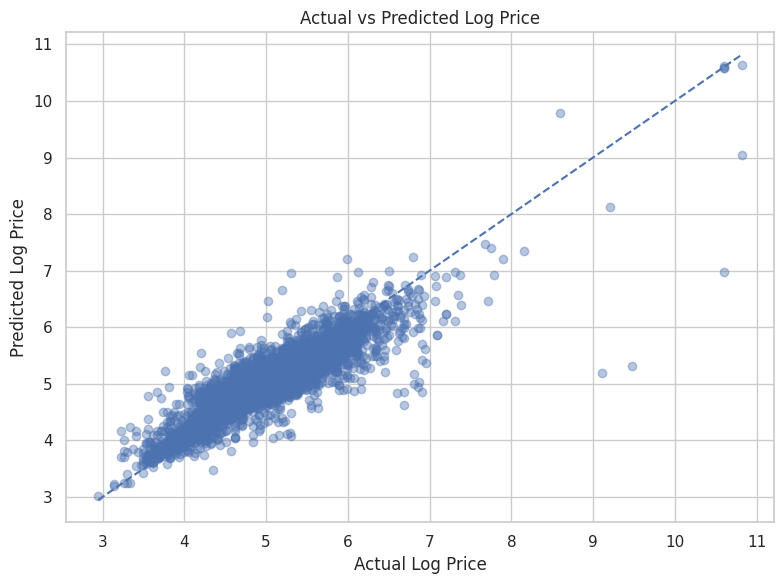

                                               feature  importance
20                      cat__room_type_Entire home/apt        0.23
1                                       num__bathrooms        0.14
63                    cat__property_type_Room in hotel        0.07
0                                    num__accommodates        0.06
14                           num__host_acceptance_rate        0.05
17                                    cat__city_Boston        0.04
2                                        num__bedrooms        0.04
5                                num__availability_365        0.04
4                                  num__minimum_nights        0.03
10                         num__review_scores_location        0.03
12                      num__estimated_occupancy_l365d        0.03
7                               num__reviews_per_month        0.02
3                                            num__beds        0.02
6                               num__number_of_reviews        

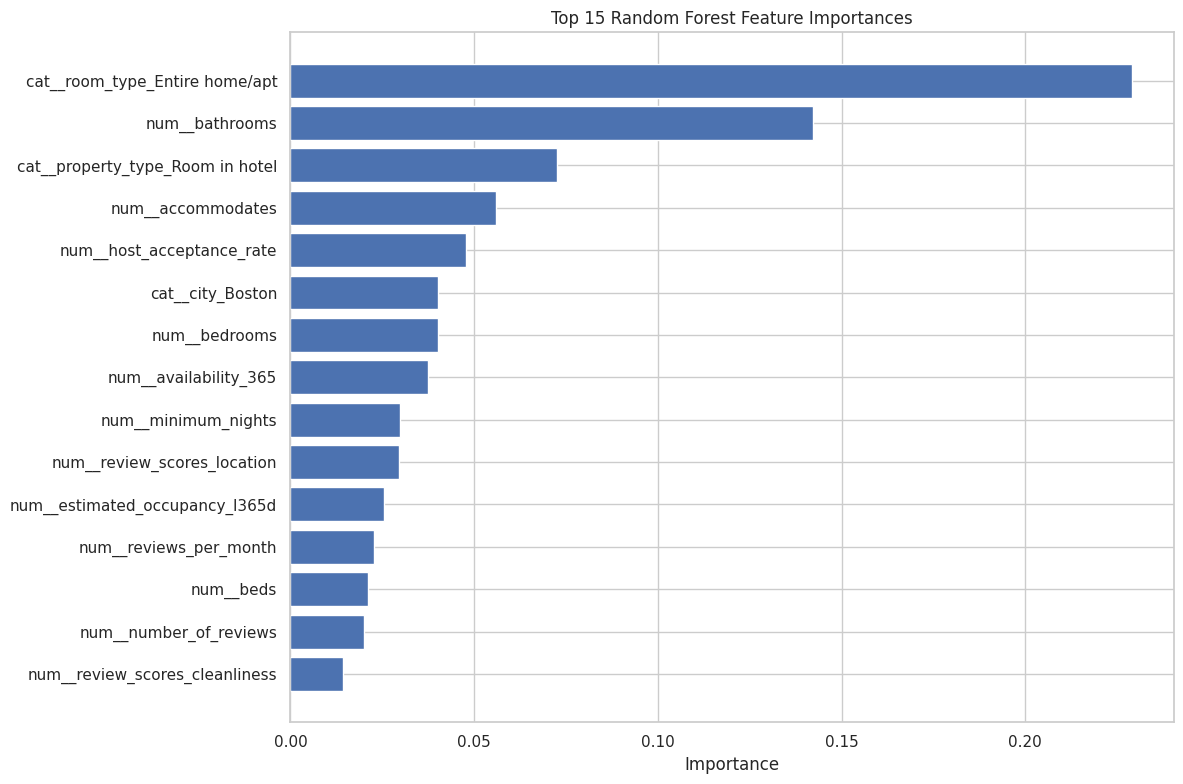

In [48]:
# REGRESSION DIAGNOSTICS
best_pred = rf_reg_pred

plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg, best_pred, alpha=0.4)
plt.xlabel("Actual Log Price")
plt.ylabel("Predicted Log Price")
plt.title("Actual vs Predicted Log Price")
min_val = min(y_test_reg.min(), best_pred.min())
max_val = max(y_test_reg.max(), best_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.tight_layout()
plt.show()

rf_fitted = rf_reg_model.named_steps["model"]
preprocessor_fitted = rf_reg_model.named_steps["preprocessor"]
feature_names = preprocessor_fitted.get_feature_names_out()

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_fitted.feature_importances_
}).sort_values("importance", ascending=False)

print(importance_df.head(20))

plt.figure(figsize=(12, 8))
top_imp = importance_df.head(15).sort_values("importance", ascending=True)
plt.barh(top_imp["feature"], top_imp["importance"])
plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

# Classification Modeling
The analysis is extended to a classification framework by predicting whether a listing belongs to a high-revenue category. Both Logistic Regression and Random Forest classifiers achieve strong performance, with accuracy, precision, recall, and F1-scores all approximately 0.94. The confusion matrix further demonstrates balanced predictive performance across both classes, indicating that the model effectively distinguishes between higher and lower performing listings. These results suggest that the selected features are highly informative for identifying successful Airbnb listings. This approach complements regression by categorizing listings into high- and low-performing groups, enabling a clearer interpretation of factors associated with success.

In [49]:
# CLASSIFICATION SETUP
classification_target = "high_revenue" if "high_revenue" in final_df.columns else "high_price"

classification_features = [
    "city",
    "room_type",
    "property_type",
    "neighbourhood_cleansed",
    "accommodates",
    "bathrooms",
    "bedrooms",
    "beds",
    "minimum_nights",
    "availability_365",
    "number_of_reviews",
    "reviews_per_month",
    "review_scores_rating",
    "review_scores_cleanliness",
    "review_scores_location",
    "review_scores_value",
    "estimated_occupancy_l365d",
    "host_response_rate",
    "host_acceptance_rate",
    "host_is_superhost",
    "host_listings_count",
    "host_total_listings_count",
    "instant_bookable",
    "amenity_count",
    "host_tenure_days"
]

classification_features = [c for c in classification_features if c in final_df.columns]

clf_df = final_df[[classification_target] + classification_features].copy()
clf_df = clf_df.dropna(subset=[classification_target])

X_clf = clf_df[classification_features]
y_clf = clf_df[classification_target]

categorical_features_clf = [c for c in X_clf.columns if X_clf[c].dtype == "object"]
numeric_features_clf = [c for c in X_clf.columns if c not in categorical_features_clf]

print("Classification target:", classification_target)
print("Rows:", clf_df.shape[0])
print(y_clf.value_counts(normalize=True))

Classification target: high_revenue
Rows: 17140
high_revenue
1   0.50
0   0.50
Name: proportion, dtype: float64


In [50]:
# CLASSIFICATION MODELS
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

preprocessor_clf = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features_clf),
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_features_clf)
    ]
)

log_model = Pipeline(steps=[
    ("preprocessor", preprocessor_clf),
    ("model", LogisticRegression(max_iter=3000))
])

rf_clf_model = Pipeline(steps=[
    ("preprocessor", preprocessor_clf),
    ("model", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

log_model.fit(X_train_clf, y_train_clf)
rf_clf_model.fit(X_train_clf, y_train_clf)

log_pred = log_model.predict(X_test_clf)
rf_clf_pred = rf_clf_model.predict(X_test_clf)

classification_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest Classifier"],
    "Accuracy": [
        accuracy_score(y_test_clf, log_pred),
        accuracy_score(y_test_clf, rf_clf_pred)
    ],
    "Precision": [
        precision_score(y_test_clf, log_pred, zero_division=0),
        precision_score(y_test_clf, rf_clf_pred, zero_division=0)
    ],
    "Recall": [
        recall_score(y_test_clf, log_pred, zero_division=0),
        recall_score(y_test_clf, rf_clf_pred, zero_division=0)
    ],
    "F1": [
        f1_score(y_test_clf, log_pred, zero_division=0),
        f1_score(y_test_clf, rf_clf_pred, zero_division=0)
    ]
})

print(classification_results)

print("\nLogistic Regression")
print(classification_report(y_test_clf, log_pred, zero_division=0))

print("\nRandom Forest Classifier")
print(classification_report(y_test_clf, rf_clf_pred, zero_division=0))

                      Model  Accuracy  Precision  Recall   F1
0       Logistic Regression      0.94       0.94    0.94 0.94
1  Random Forest Classifier      0.94       0.94    0.94 0.94

Logistic Regression
              precision    recall  f1-score   support

           0       0.94      0.94      0.94      1706
           1       0.94      0.94      0.94      1722

    accuracy                           0.94      3428
   macro avg       0.94      0.94      0.94      3428
weighted avg       0.94      0.94      0.94      3428


Random Forest Classifier
              precision    recall  f1-score   support

           0       0.94      0.94      0.94      1706
           1       0.94      0.94      0.94      1722

    accuracy                           0.94      3428
   macro avg       0.94      0.94      0.94      3428
weighted avg       0.94      0.94      0.94      3428



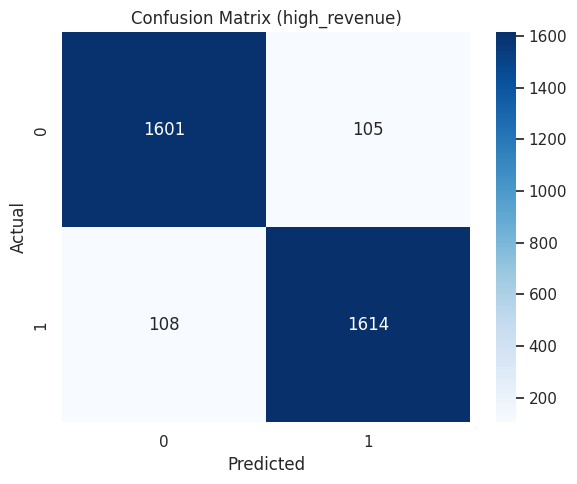

In [53]:
# CONFUSION MATRIX
best_clf_pred = rf_clf_pred

cm = confusion_matrix(y_test_clf, best_clf_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix ({classification_target})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [54]:
# CITY-BY-CITY REGRESSION COMPARISON
city_model_results = []

city_features = [
    "room_type",
    "property_type",
    "neighbourhood_cleansed",
    "accommodates",
    "bathrooms",
    "bedrooms",
    "beds",
    "minimum_nights",
    "availability_365",
    "number_of_reviews",
    "reviews_per_month",
    "review_scores_rating",
    "review_scores_cleanliness",
    "review_scores_location",
    "review_scores_value",
    "estimated_occupancy_l365d",
    "host_response_rate",
    "host_acceptance_rate",
    "host_is_superhost",
    "host_listings_count",
    "host_total_listings_count",
    "instant_bookable",
    "amenity_count",
    "host_tenure_days"
]

city_features = [c for c in city_features if c in final_df.columns]

for city in final_df["city"].dropna().unique():
    sub = final_df[final_df["city"] == city].copy()
    sub = sub[["log_price"] + city_features].dropna(subset=["log_price"])

    X_city = sub[city_features]
    y_city = sub["log_price"]

    cat_city = [c for c in X_city.columns if X_city[c].dtype == "object"]
    num_city = [c for c in X_city.columns if c not in cat_city]

    if len(sub) < 200:
        continue

    X_train_city, X_test_city, y_train_city, y_test_city = train_test_split(
        X_city, y_city, test_size=0.2, random_state=42
    )

    pre_city = ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]), num_city),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]), cat_city)
        ]
    )

    model_city = Pipeline([
        ("preprocessor", pre_city),
        ("model", RandomForestRegressor(n_estimators=250, random_state=42, n_jobs=-1))
    ])

    model_city.fit(X_train_city, y_train_city)
    pred_city = model_city.predict(X_test_city)

    city_model_results.append({
        "city": city,
        "rows": len(sub),
        "MAE": mean_absolute_error(y_test_city, pred_city),
        "RMSE": np.sqrt(mean_squared_error(y_test_city, pred_city)),
        "R2": r2_score(y_test_city, pred_city)
    })

city_model_results = pd.DataFrame(city_model_results)
print(city_model_results)

      city  rows  MAE  RMSE   R2
0  Chicago  7562 0.27  0.37 0.79
1   Boston  3450 0.22  0.37 0.76
2  Seattle  6128 0.24  0.33 0.71


In [55]:
# CORRELATIONS WITH LOG PRICE
numeric_only_df = final_df.select_dtypes(include=[np.number]).copy()

price_corr = (
    numeric_only_df.corr(numeric_only=True)["log_price"]
    .sort_values(ascending=False)
    .drop("log_price")
)

print("Top positive correlations with log_price:")
print(price_corr.head(10))

print("\nTop negative correlations with log_price:")
print(price_corr.tail(10))

Top positive correlations with log_price:
high_price                  0.74
accommodates                0.54
bedrooms                    0.46
beds                        0.46
price                       0.42
bathrooms                   0.39
estimated_revenue_l365d     0.20
high_revenue                0.19
review_scores_location      0.18
review_scores_cleanliness   0.15
Name: log_price, dtype: float64

Top negative correlations with log_price:
log_estimated_revenue_l365d    0.02
number_of_reviews_ltm         -0.01
host_identity_verified        -0.01
high_demand                   -0.01
number_of_reviews_l30d        -0.05
latitude                      -0.06
number_of_reviews             -0.06
log_number_of_reviews         -0.07
estimated_occupancy_l365d     -0.09
minimum_nights                -0.09
Name: log_price, dtype: float64


# Conclusion
Overall, the findings indicate that Airbnb pricing and performance are driven by a combination of property characteristics, host attributes, and location-based factors. The superior performance of Random Forest models highlights the importance of capturing nonlinear relationships in pricing dynamics, while classification results demonstrate that high-performing listings can be reliably identified using observable features. These insights offer practical implications for Airbnb hosts and suggest avenues for further research, including expanding the analysis to additional cities and incorporating more advanced modeling techniques.